In [77]:
import torch
import torch.nn as nn
import torch.optim as optim
from rich.progress import Progress
import numpy as np
import re
import torch.nn.functional as F
import os
import pickle
import matplotlib.pyplot as plt
from rich.progress import track

In [78]:
import urllib.request

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

with urllib.request.urlopen(url) as response:
    text = response.read().decode("utf-8")

# Use just the first 50,000 characters (mini slice)
mini_text = text[:50000]

In [79]:
charToIndex = {c:i for i,c in enumerate(sorted(set(mini_text)))}
indexToChar = {i:c for i,c in enumerate(sorted(set(mini_text)))}

In [80]:
seq_len = 10

X = []
y = []

for i in range(len(mini_text)-seq_len):
  X.append([charToIndex[char] for char in mini_text[i:i+seq_len]])
  y.append([charToIndex[char] for char in mini_text[i+seq_len]])

X = torch.tensor(X)
y = torch.tensor(y)

In [81]:
class GRUModel(nn.Module):
  def __init__(self, vocab_size):
    super().__init__()

    self.embedding = nn.Embedding(vocab_size, 64)
    self.gru = nn.LSTM(64, 128, batch_first=True)
    self.linear = nn.Linear(128, vocab_size)

  def forward(self,x):
    x = self.embedding(x)
    out, _ = self.gru(x)
    out = out[:,-1,:]
    out = self.linear(out)

    return out

In [82]:
model = GRUModel(len(charToIndex))

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.01)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-5)

In [83]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

Using device: cuda


GRUModel(
  (embedding): Embedding(59, 64)
  (gru): LSTM(64, 128, batch_first=True)
  (linear): Linear(in_features=128, out_features=59, bias=True)
)

In [84]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 64
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=batch_size,drop_last=True, shuffle=True)

### Moving Model and Data to GPU

Output()

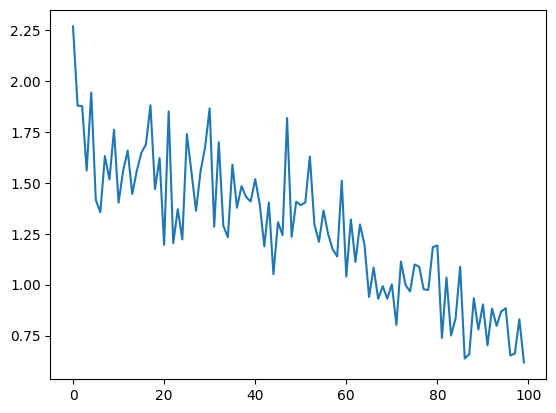

In [85]:
model.train()
LOSS = []
EPOCHS = 100
epoch_loss = None
for epoch in track(range(EPOCHS),description="Training Data:"):
    for batch_X, batch_y in dataloader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        output = model.forward(batch_X)

        loss = loss_fn(output, batch_y.squeeze(-1))
        optimizer.zero_grad()
        epoch_loss = loss.item()
        loss.backward()
        total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss = loss.item()
    LOSS.append(epoch_loss)
    scheduler.step()
plt.plot(list(range(EPOCHS)),LOSS)
plt.show()

In [ ]:
def generate_response(model,text,max_tokens=20, temperature=0.8, top_k=0, top_p=0.75):

  char_data = [charToIndex[char] for char in text]

  model.eval()
  with torch.no_grad():
    for i in range(max_tokens):
      data = torch.tensor([char_data])
      data = data.to(device)

      output = model(data)
      # print("output shape :",output.unsqueeze(0))
      probabilities = F.softmax(output / temperature, dim=-1)
      # print(probabilities)
      if top_p < 1.0:
          sorted_probs, sorted_indices = torch.sort(probabilities, descending=True)
          cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
          num_to_keep = (cumulative_probs < top_p).sum(dim=-1) + 1
          # print(num_to_keep)
          mask = torch.arange(probabilities.shape[-1], device=probabilities.device).unsqueeze(0) < num_to_keep.unsqueeze(1)
          # print(probabilities.shape[-1])
          filtered_sorted_probs = sorted_probs * mask
          # print(filtered_sorted_probs)

          probabilities = torch.zeros_like(probabilities).scatter_(-1, sorted_indices, filtered_sorted_probs)
          probabilities = probabilities / probabilities.sum(dim=-1, keepdim=True)
      elif top_k > 0:
          values, indices = torch.topk(probabilities, k=top_k, dim=-1)
          probabilities = torch.zeros_like(probabilities).scatter_(-1, indices, values)
          probabilities = probabilities / probabilities.sum(dim=-1, keepdim=True)
      # print(probabilities)



      char_idx = torch.multinomial(probabilities, 1).item()
      # print(probabilities)
      predicted_char = indexToChar[char_idx]

      char_data.append(char_idx)
      text = text + predicted_char

  return f"{''.join(text)}"

text = input('enter text: ').strip().lower()

response = generate_response(model,text,max_tokens=1000, temperature=1, top_k=0, top_p=0.75)

print(str(response))